<a href="https://colab.research.google.com/github/DEESHA-AFK/T076-ARTIFICIAL-INTELLIGENCE-PRACTICAL/blob/main/T076_DEESHA_CHAVAN_AI_PRAC_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optimal Path Discovered: Versova -> JP Rd/Versova Marg -> Juhu Versova Link Rd Jn -> Gurunanak Rd/Turner Rd (via SV Road) -> Bandra Station (West)
Total Road Distance: 10.486 km



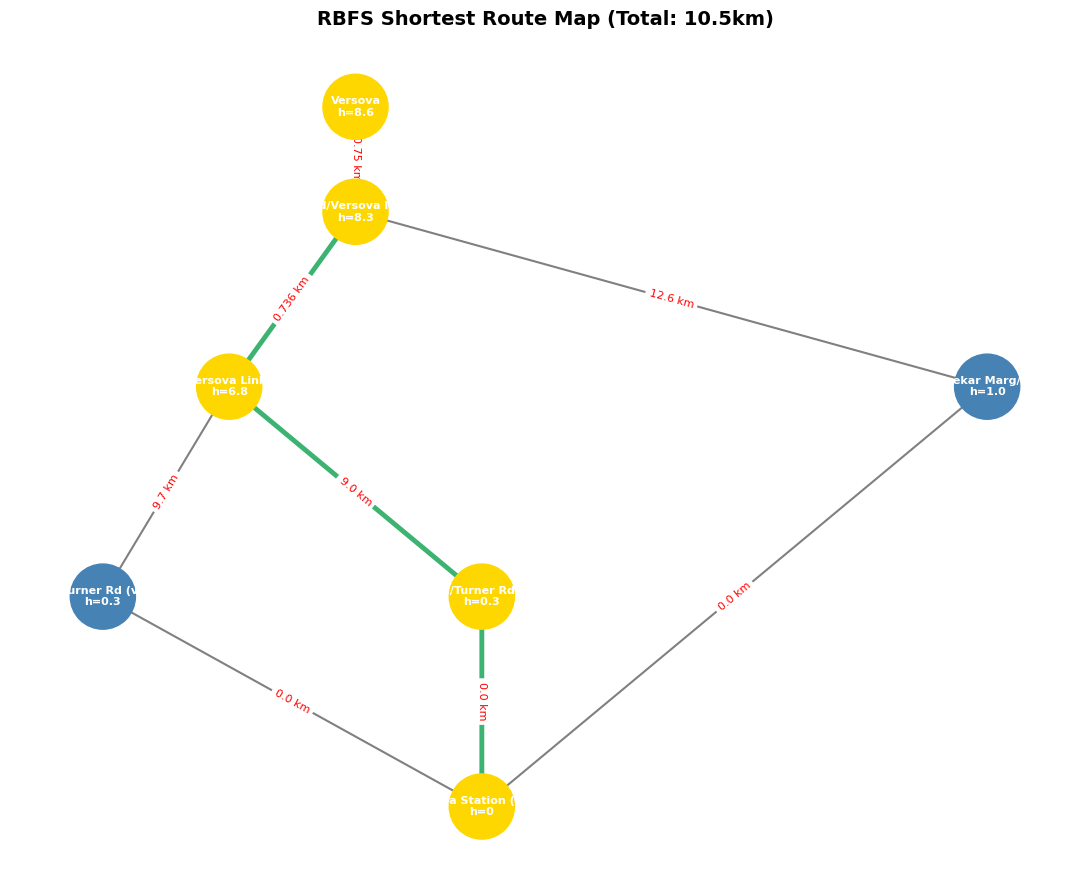

In [5]:
"""
Recursive Best-First Search (RBFS) in AI
RBFS algorithm for solving a pathfinding problem: Versova to Bandra.
"""

import math
import matplotlib.pyplot as plt
import networkx as nx

# 1. DATA STRUCTURE POPULATION
graph = {
    'Versova':                                     {'JP Rd/Versova Marg': 0.75},
    'JP Rd/Versova Marg':                           {'Anant Kanekar Marg/Station Rd': 12.6,
                                                       'Juhu Versova Link Rd Jn': 0.736},
    'Juhu Versova Link Rd Jn':                        {'Gurunanak Rd/Turner Rd (via Juhu Tara Rd)': 9.7,
                                                         'Gurunanak Rd/Turner Rd (via SV Road)': 9.0},
    'Anant Kanekar Marg/Station Rd':                   {'Bandra Station (West)': 0.0},
    'Gurunanak Rd/Turner Rd (via Juhu Tara Rd)':          {'Bandra Station (West)': 0.0},
    'Gurunanak Rd/Turner Rd (via SV Road)':                {'Bandra Station (West)': 0.0},
    'Bandra Station (West)':                                {}
}

heuristics = {
    'Versova': 8.6,
    'JP Rd/Versova Marg': 8.3,
    'Juhu Versova Link Rd Jn': 6.8,
    'Anant Kanekar Marg/Station Rd': 1.0,
    'Gurunanak Rd/Turner Rd (via Juhu Tara Rd)': 0.3,
    'Gurunanak Rd/Turner Rd (via SV Road)': 0.3,
    'Bandra Station (West)': 0
}

node_positions = {
    'Versova':                                     (1, 10),
    'JP Rd/Versova Marg':                            (1, 8.5),
    'Anant Kanekar Marg/Station Rd':                   (3.5, 6),
    'Juhu Versova Link Rd Jn':                          (0.5, 6),
    'Gurunanak Rd/Turner Rd (via Juhu Tara Rd)':           (0, 3),
    'Gurunanak Rd/Turner Rd (via SV Road)':                 (1.5, 3),
    'Bandra Station (West)':                                 (1.5, 0)
}


# 2. RECURSIVE BEST-FIRST SEARCH (RBFS) ALGORITHM
def rbfs(graph, heuristics, goal, node, f_limit):
    """
    node     : dict with 'path', 'g', 'f'
    f_limit  : the bound this call must not exceed
    returns  : (result_node_or_None, revised_f_value)
    """
    current = node['path'][-1]

    if current == goal:
        return node, node['f']

    successors = []
    for neighbor, edge_cost in graph[current].items():
        if neighbor in node['path']:
            continue
        g = node['g'] + edge_cost
        h = heuristics[neighbor]
        f = max(g + h, node['f'])
        successors.append({'path': node['path'] + [neighbor], 'g': g, 'f': f})

    if not successors:
        return None, math.inf

    while True:
        successors.sort(key=lambda s: s['f'])
        best = successors[0]

        if best['f'] > f_limit:
            return None, best['f']

        alternative_f = successors[1]['f'] if len(successors) > 1 else math.inf

        result, best['f'] = rbfs(graph, heuristics, goal, best,
                                  min(f_limit, alternative_f))

        if result is not None:
            return result, best['f']


def rbfs_search(graph, heuristics, start, goal):
    root = {'path': [start], 'g': 0, 'f': heuristics[start]}
    result, _ = rbfs(graph, heuristics, goal, root, math.inf)
    if result is None:
        return None, float('inf')
    return result['path'], result['g']

optimal_path, total_distance = rbfs_search(graph, heuristics, 'Versova', 'Bandra Station (West)')
print(f"Optimal Path Discovered: {' -> '.join(optimal_path)}")
print(f"Total Road Distance: {total_distance} km\n")

# 3. GRAPH PLOTTING AND VISUALIZATION
G = nx.DiGraph()
for node, neighbors in graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)

plt.figure(figsize=(11, 9))

path_edges = list(zip(optimal_path, optimal_path[1:]))
normal_edges = [edge for edge in G.edges() if edge not in path_edges]

path_node_set = set(optimal_path)
node_colors = ['gold' if node in path_node_set else 'steelblue' for node in G.nodes()]

nx.draw_networkx_nodes(G, node_positions, node_size=2200, node_color=node_colors)
nx.draw_networkx_edges(G, node_positions, edgelist=normal_edges, width=1.5, edge_color='gray', arrows=True)

nx.draw_networkx_edges(G, node_positions, edgelist=path_edges, width=3.5, edge_color='mediumseagreen', arrows=True)

node_labels = {node: f"{node}\nh={heuristics[node]}" for node in G.nodes()}
nx.draw_networkx_labels(G, node_positions, labels=node_labels, font_size=8, font_weight='bold', font_color='white')

edge_labels = nx.get_edge_attributes(G, 'weight')
formatted_edge_labels = {k: f"{v} km" for k, v in edge_labels.items()}
nx.draw_networkx_edge_labels(G, node_positions, edge_labels=formatted_edge_labels, font_color='red', font_size=8)

plt.title(f"RBFS Shortest Route Map (Total: {round(total_distance, 1)}km)", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('rbfs_versova_bandra.png', dpi=150)
plt.show()